In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import pearsonr

In [4]:
# Load dataset
cyber = pd.read_csv("salaries_cyber.csv")

Pearson Correlation (r) between Remote Ratio and Salary:  0.17452267314719297
P-value: 5.490864060035908e-10


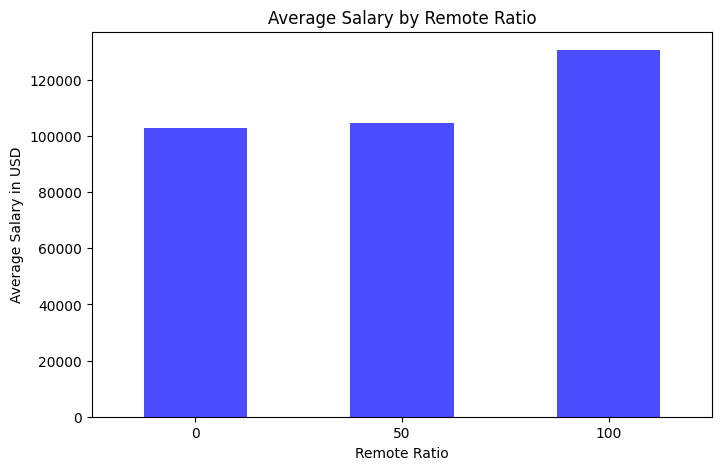

In [5]:
# Data Cleaning: Convert salary to numeric, handle missing values
cyber = cyber.dropna()
cyber['salary_in_usd'] = pd.to_numeric(cyber['salary_in_usd'], errors = "coerce")

# Graph 1: Bar Graph - Average Salary by Remote Ratio
# For the new graph that we learned, I used a bar graph that was introduced in the "DataCleaning" notes

# Pearson correlation requires no missing values between the two columns
valid_data = cyber[["remote_ratio", "salary_in_usd"]].dropna()

# Getting the pearsonr correlation score and getting the p_value from the valid data that we created
pearson_corr, p_value = pearsonr(valid_data["remote_ratio"], valid_data["salary_in_usd"])
print("Pearson Correlation (r) between Remote Ratio and Salary: ", pearson_corr)
print("P-value:", p_value)


plt.figure(figsize = (8, 5))
avg_salary_remote = cyber.groupby("remote_ratio")["salary_in_usd"].mean()
avg_salary_remote.plot(kind = "bar", color = "blue", alpha = 0.7)
plt.title("Average Salary by Remote Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Average Salary in USD")
plt.xticks(rotation = 0)
plt.show()

Pearson Correlation (r) between Experience Level and Salary: 0.5082810535631893
P-value: 7.017515703031333e-83


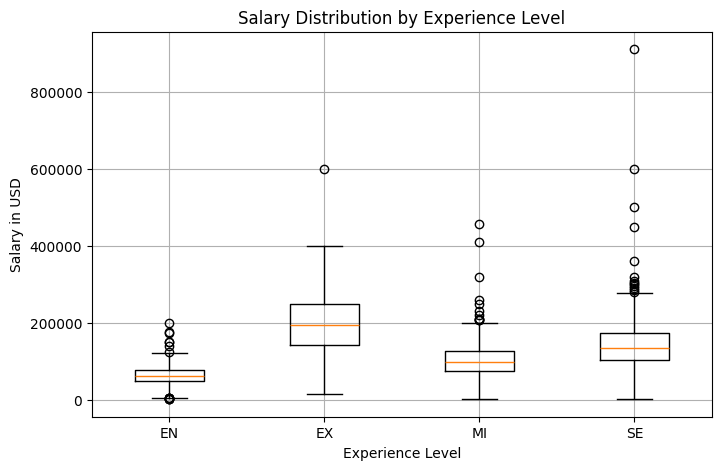

In [6]:
# To do Pearson correlation, experience_level must be numeric
# We'll map experience levels to numbers manually
experience_mapping = {
    "EN": 1,  # Entry-level
    "MI": 2,  # Mid-level
    "SE": 3,  # Senior-level
    "EX": 4   # Executive-level
}

# Create a new numeric column for experience level
cyber["experience_numeric"] = cyber["experience_level"].map(experience_mapping)

# Drop rows with missing mappings (if any)
valid_data_exp = cyber[["experience_numeric", "salary_in_usd"]].dropna()

# Perform Pearson correlation
pearson_corr_exp, p_value_exp = pearsonr(valid_data_exp["experience_numeric"], valid_data_exp["salary_in_usd"])
print("Pearson Correlation (r) between Experience Level and Salary:", pearson_corr_exp)
print("P-value:", p_value_exp)

# Extract unique experience levels and sort them for consistent ordering
experience_levels = sorted(cyber["experience_level"].unique())

# Prepare salary data grouped by experience level
data = [cyber[cyber["experience_level"] == level]["salary_in_usd"] for level in experience_levels]

# Create the boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(data,tick_labels = experience_levels)
plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary in USD")
plt.grid(True)
plt.show()

# Resources: 
# https://realpython.com/python-mappings/ 

Pearson Correlation (r) between Company Size and Salary: 0.0695
P-value: 0.01412


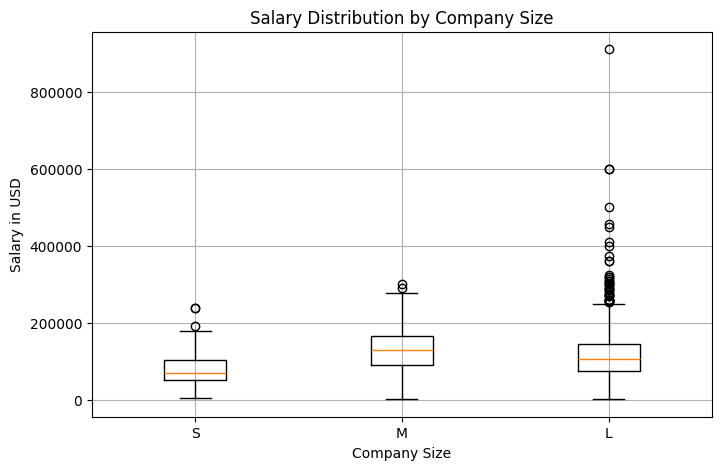

In [8]:
# Graph 2: Box and Whiskers Plot - Salary Distribution by Company Size
# For the new graph that we learned, I used a bar graph that was introduced in the "DataCleaning" notes
# Like experience levels, company size must be numeric
# We'll map company sizes to numbers manually
company_size_mapping = {
    'S': 1,  # Small
    'M': 2,  # Medium
    'L': 3   # Large
}

# Create a new numeric column for company size
cyber['company_size_numeric'] = cyber['company_size'].map(company_size_mapping)

# Drop rows with missing mappings (if any)
valid_data_comp = cyber[["company_size_numeric", "salary_in_usd"]].dropna()

# Perform Pearson correlation
pearson_corr_comp, p_value_comp = pearsonr(valid_data_comp["company_size_numeric"], valid_data_comp["salary_in_usd"])
print(f"Pearson Correlation (r) between Company Size and Salary: {pearson_corr_comp:.4f}")
print(f"P-value: {p_value_comp:.4g}")

# Graph 2: Box and Whiskers Plot - Salary Distribution by Company Size
plt.figure(figsize=(8, 5))
company_sizes = cyber["company_size"].unique()
data = [cyber[cyber["company_size"] == size]["salary_in_usd"] for size in company_sizes]
plt.boxplot(data, tick_labels=company_sizes)
plt.title("Salary Distribution by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary in USD")
plt.grid(True)
plt.show()

# Resources: 
# https://realpython.com/python-mappings/ 